<a href="https://colab.research.google.com/github/kirtisingh-001/kirtisingh-001-DataScience_Day_wise_work/blob/main/CapstoneProject2(Updated_with_scenario).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Student Success & Career Path  - Sheet1 (2).csv to Student Success & Career Path  - Sheet1 (2).csv


In [ ]:
import os
print(os.listdir())


['.config', 'Student Success & Career Path  - Sheet1 (2).csv', 'sample_data']


Columns in Dataset:
Index(['student_id', 'hours_studied', 'attendance_(%)',
       'assignments_submitted', 'previous_sem_gpa', 'participation_score',
       'final_exam_score', 'pass_fail', 'career_readiness_score', 'age',
       'gender'],
      dtype='object')

Dataset Preview:
  student_id  hours_studied  attendance_(%)  assignments_submitted  \
0       S001             10              85                      8   
1       S002              5              60                      5   
2       S003             12              90                      9   
3       S004              3              40                      3   
4       S005              8              75                      7   

   previous_sem_gpa  participation_score  final_exam_score pass_fail  \
0               3.2                   70                78      Pass   
1               2.5                   55                55      Fail   
2               3.8                   80                88      Pass   
3        

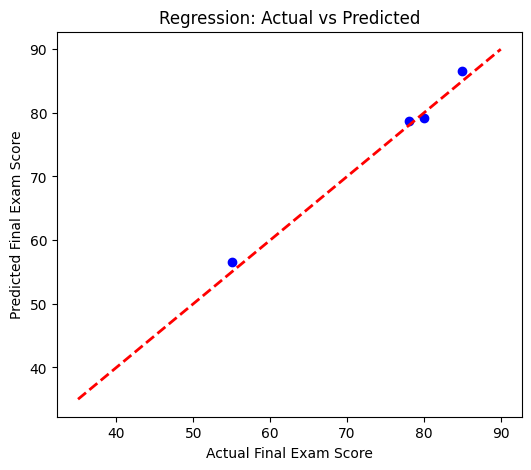

CLASSIFICATION MODEL

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4

 CLUSTERING MODEL
Cluster Distribution:
cluster
1    9
2    6
0    5
Name: count, dtype: int64


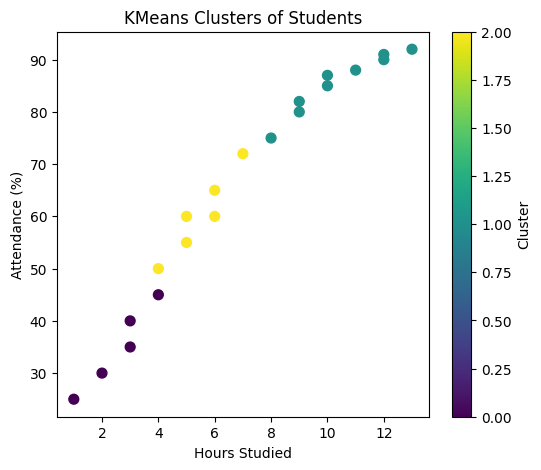

RECOMMENDATION SYSTEM
   final_exam_score  status  cluster         recommendation
0                78       1        1  On Track - Keep Going
1                55       0        2         Extra Tutoring
2                88       1        1  On Track - Keep Going
3                45       0        0         Extra Tutoring
4                70       1        1  On Track - Keep Going


In [ ]:
#Capstone Project: Student Success & Career Path Prediction
#Scenario
#The university wants to analyze student performance data to:
#Predict exam scores (Regression).
#Classify students into “At Risk” vs. “On Track” categories (Classification).
#Cluster students into groups with similar study habits (Clustering).
#Recommend interventions (extra tutoring, workshops, counseling).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, r2_score, classification_report
df = pd.read_csv("Student Success & Career Path  - Sheet1 (2).csv")
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print("Columns in Dataset:")
print(df.columns)
print("\nDataset Preview:")
print(df.head())
df = df.dropna()
print("REGRESSION MODEL")
X = df[["hours_studied", "attendance_(%)", "assignments_submitted"]]
y = df["final_exam_score"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)
y_pred = reg_model.predict(X_test)
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("Actual Final Exam Score")
plt.ylabel("Predicted Final Exam Score")
plt.title("Regression: Actual vs Predicted")
plt.show()
print("CLASSIFICATION MODEL")
df["status"] = np.where(df["final_exam_score"] < 60, 0, 1)
X_class = df[["hours_studied", "attendance_(%)", "assignments_submitted"]]
y_class = df["status"]
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_c = scaler.fit_transform(X_train_c)
X_test_c = scaler.transform(X_test_c)
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_c, y_train_c)
y_pred_c = clf.predict(X_test_c)
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_c))

print(" CLUSTERING MODEL")
scaler_cluster = StandardScaler()
X_scaled = scaler_cluster.fit_transform(
    df[["hours_studied", "attendance_(%)", "assignments_submitted"]]
)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)
print("Cluster Distribution:")
print(df["cluster"].value_counts())
plt.figure(figsize=(6,5))
plt.scatter(df["hours_studied"], df["attendance_(%)"], c=df["cluster"], cmap='viridis', s=50)
plt.xlabel("Hours Studied")
plt.ylabel("Attendance (%)")
plt.title("KMeans Clusters of Students")
plt.colorbar(label="Cluster")
plt.show()

print("RECOMMENDATION SYSTEM")
def recommend(row):
    if row["status"] == 0:
        return "Extra Tutoring"
    elif row["cluster"] == 2:
        return "Time Management Workshop"
    else:
        return "On Track - Keep Going"
df["recommendation"] = df.apply(recommend, axis=1)
print(df[["final_exam_score", "status", "cluster", "recommendation"]].head())
df.to_csv("final_student_analysis.csv", index=False)